# ANALISIS DEL DATO

In [21]:
import pandas as pd
import numpy as np

df_final = pd.read_csv('../data/processed/dataset_final.csv')
print(f"Dataset cargado: {df_final.shape[0]} filas x {df_final.shape[1]} columnas")
print(df_final.head())

Dataset cargado: 58 filas x 17 columnas
  periodo  concursos  tasa_paro  tasa_morosidad  euribor_12m  \
0  2011Q3       1206      21.28         10.1981       2.1142   
1  2011Q4       1649      22.56         11.3208       2.0524   
2  2012Q1       2046      24.19         12.0786       1.6710   
3  2012Q2       2092      24.40         14.4031       1.2813   
4  2012Q3       1523      24.79         16.0266       0.8969   

   coste_construccion  coste_industria  coste_servicios     ipc  ipri_consumo  \
0             2517.27          2796.76          2381.58  76.319        90.063   
1             2834.83          3092.36          2585.97  77.320        90.288   
2             2584.73          2863.67          2439.34  76.864        90.766   
3             2791.10          2986.66          2496.81  78.194        91.401   
4             2543.53          2847.04          2370.98  78.425        92.578   

   ipri_energia  ipri_intermedios  pib_var_trimestral  precio_eur_mwh  \
0        81.037

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import subprocess

# Instalación de dependencias necesarias
subprocess.run(['pip', 'install', 'statsmodels'], capture_output=True)
subprocess.run(['pip', 'install', 'xgboost'], capture_output=True)

warnings.filterwarnings('ignore')

# Carga del dataset final construido en el notebook de ingeniería del dato
df_final = pd.read_csv('../data/processed/dataset_final.csv')
print(f"Dataset cargado: {df_final.shape[0]} filas x {df_final.shape[1]} columnas")
print(f"Período: {df_final['periodo'].iloc[0]} — {df_final['periodo'].iloc[-1]}")

# Variables numéricas (excluimos el identificador temporal)
variables_num = df_final.drop(columns=['periodo'])



Dataset cargado: 58 filas x 17 columnas
Período: 2011Q3 — 2025Q4


## MODELADO PREDICTIVO

In [23]:

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

#  1. DIVISIÓN TRAIN / TEST 
# En series temporales la división debe respetar el orden cronológico.
# Se reserva el 85% para entrenamiento y el 15% restante para test,
# lo que deja aproximadamente 9 trimestres recientes como conjunto de evaluación.
corte = int(len(df_final) * 0.85)
df_train = df_final.iloc[:corte].copy()
df_test  = df_final.iloc[corte:].copy()

features = [c for c in df_final.columns if c not in ['periodo', 'concursos']]
X_train = df_train[features]
y_train = df_train['concursos']
X_test  = df_test[features]
y_test  = df_test['concursos']

print(f"\nTrain: {len(df_train)} obs ({df_train['periodo'].iloc[0]} — {df_train['periodo'].iloc[-1]})")
print(f"Test:  {len(df_test)} obs ({df_test['periodo'].iloc[0]} — {df_test['periodo'].iloc[-1]})")

#  2. PREPROCESAMIENTO 
# El escalado es necesario para la Regresión Lineal, ya que sus coeficientes
# son sensibles a la escala de las variables. Random Forest y XGBoost no lo
# requieren al operar mediante divisiones del espacio de características.
# El scaler se ajusta SOLO sobre train para evitar fuga de información del test.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Validación cruzada temporal: cada fold respeta el orden cronológico,
# evitando que el modelo entrene con datos futuros respecto al período de validación.
tscv = TimeSeriesSplit(n_splits=5)

#  3. ENTRENAMIENTO 

# — Regresión Lineal (modelo baseline) —
# Sirve como referencia mínima de rendimiento. Su simplicidad lo hace
# interpretable y robusto cuando el número de observaciones es reducido.
modelo_rl = LinearRegression()
modelo_rl.fit(X_train_sc, y_train)
pred_rl = modelo_rl.predict(X_test_sc)
print("\nRegresión Lineal entrenada")

# — Random Forest —
# Modelo de ensamble basado en árboles de decisión con bagging.
# El GridSearchCV busca la combinación óptima de hiperparámetros
# usando validación cruzada temporal para evitar sobreajuste.
param_grid_rf = {
    'n_estimators':      [100, 200, 300],   # número de árboles
    'max_depth':         [3, 5, 7],          # profundidad máxima de cada árbol
    'min_samples_split': [5, 10],            # mínimo de muestras para dividir un nodo
    'min_samples_leaf':  [2, 4]              # mínimo de muestras en una hoja
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf,
                       cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_train, y_train)
modelo_rf = grid_rf.best_estimator_
pred_rf   = modelo_rf.predict(X_test)
print(f" Random Forest entrenado — mejores parámetros: {grid_rf.best_params_}")

# — XGBoost —
# Modelo de boosting por gradiente que construye árboles de forma secuencial,
# donde cada árbol corrige los errores del anterior. Se añaden parámetros de
# regularización (reg_alpha y reg_lambda) para penalizar la complejidad del
# modelo y reducir el sobreajuste, especialmente relevante con datasets pequeños.
param_grid_xgb = {
    'n_estimators':     [100, 200, 300],  # número de árboles secuenciales
    'max_depth':        [2, 3, 4],         # profundidad máxima (valores bajos evitan sobreajuste)
    'learning_rate':    [0.01, 0.05, 0.1], # tasa de aprendizaje por árbol
    'subsample':        [0.7, 0.85, 1.0],  # fracción de observaciones por árbol
    'colsample_bytree': [0.7, 0.85, 1.0],  # fracción de variables por árbol
    'reg_alpha':        [0, 0.1, 0.5],     # regularización L1 (Lasso)
    'reg_lambda':       [1, 2, 5]          # regularización L2 (Ridge)
}
grid_xgb = GridSearchCV(XGBRegressor(random_state=42, verbosity=0), param_grid_xgb,
                        cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
modelo_xgb = grid_xgb.best_estimator_
pred_xgb   = modelo_xgb.predict(X_test)
print(f"XGBoost entrenado — mejores parámetros: {grid_xgb.best_params_}")


Train: 49 obs (2011Q3 — 2023Q3)
Test:  9 obs (2023Q4 — 2025Q4)

Regresión Lineal entrenada
 Random Forest entrenado — mejores parámetros: {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
XGBoost entrenado — mejores parámetros: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'reg_alpha': 0, 'reg_lambda': 2, 'subsample': 0.7}


## EVALUACIONES


MÉTRICAS DE EVALUACIÓN:
          Modelo   RMSE    MAE      R²
Regresión Lineal 178.64 136.42 -0.2036
   Random Forest 313.07 268.72 -2.6966
         XGBoost 300.42 254.87 -2.4039


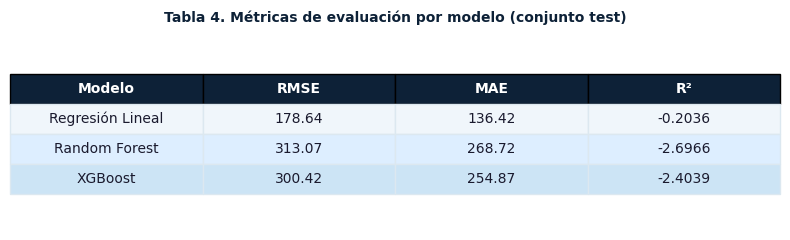

Tabla de métricas guardada


In [24]:

# Se calculan tres métricas complementarias para cada modelo:
# · RMSE: penaliza más los errores grandes, útil para detectar predicciones muy alejadas
# · MAE:  error medio absoluto, interpretable directamente en número de concursos
# · R²:   proporción de varianza explicada (1 = perfecto, 0 = equivale a predecir la media)

def evaluar(nombre, y_real, y_pred):
    return {
        'Modelo': nombre,
        'RMSE':   round(np.sqrt(mean_squared_error(y_real, y_pred)), 2),
        'MAE':    round(mean_absolute_error(y_real, y_pred), 2),
        'R²':     round(r2_score(y_real, y_pred), 4)
    }

resultados = pd.DataFrame([
    evaluar('Regresión Lineal', y_test, pred_rl),
    evaluar('Random Forest',    y_test, pred_rf),
    evaluar('XGBoost',          y_test, pred_xgb),
])
print("\nMÉTRICAS DE EVALUACIÓN:")
print(resultados.to_string(index=False))

# Tabla visual para incluir en la memoria
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axis('off')
table = ax.table(cellText=resultados.values, colLabels=resultados.columns,
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)
for j in range(len(resultados.columns)):
    table[0, j].set_facecolor('#0d2137')
    table[0, j].set_text_props(color='white', fontweight='bold')
colores = ['#f0f6fb', '#ddeeff', '#cce4f5']
for i in range(1, len(resultados) + 1):
    for j in range(len(resultados.columns)):
        table[i, j].set_facecolor(colores[i - 1])
        table[i, j].set_text_props(color='#1a1a2e')
        table[i, j].set_edgecolor('#dce8f0')
plt.title('Tabla 4. Métricas de evaluación por modelo (conjunto test)',
          fontsize=10, fontweight='bold', pad=12, color='#0d2137')
plt.tight_layout()
plt.savefig('../data/graphics/tabla_metricas.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("Tabla de métricas guardada")

## PREDICCIONES VS REALES

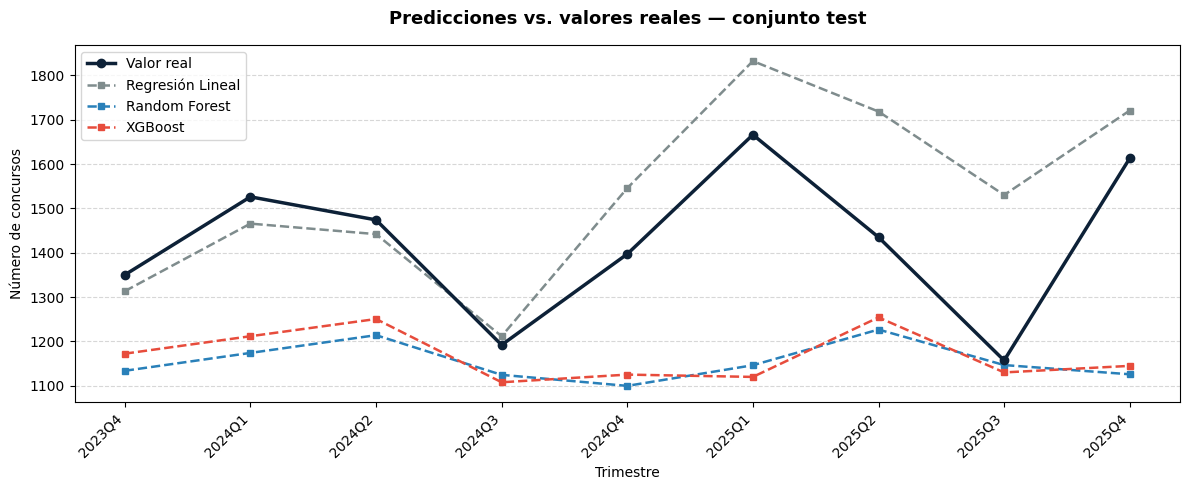

 Gráfico de predicciones guardado


In [25]:

periodos_test = df_test['periodo'].values
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(periodos_test, y_test.values, color='#0d2137', linewidth=2.5,
        marker='o', markersize=6, label='Valor real', zorder=5)
ax.plot(periodos_test, pred_rl,  color='#7f8c8d', linewidth=1.8,
        linestyle='--', marker='s', markersize=4, label='Regresión Lineal')
ax.plot(periodos_test, pred_rf,  color='#2980b9', linewidth=1.8,
        linestyle='--', marker='s', markersize=4, label='Random Forest')
ax.plot(periodos_test, pred_xgb, color='#e74c3c', linewidth=1.8,
        linestyle='--', marker='s', markersize=4, label='XGBoost')
ax.set_title('Predicciones vs. valores reales — conjunto test',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Trimestre')
ax.set_ylabel('Número de concursos')
ax.set_xticks(periodos_test)
ax.set_xticklabels(periodos_test, rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.savefig('../data/graphics/fig_predicciones_vs_reales.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Gráfico de predicciones guardado")

## IMPORTANCIA DE VARIABLES

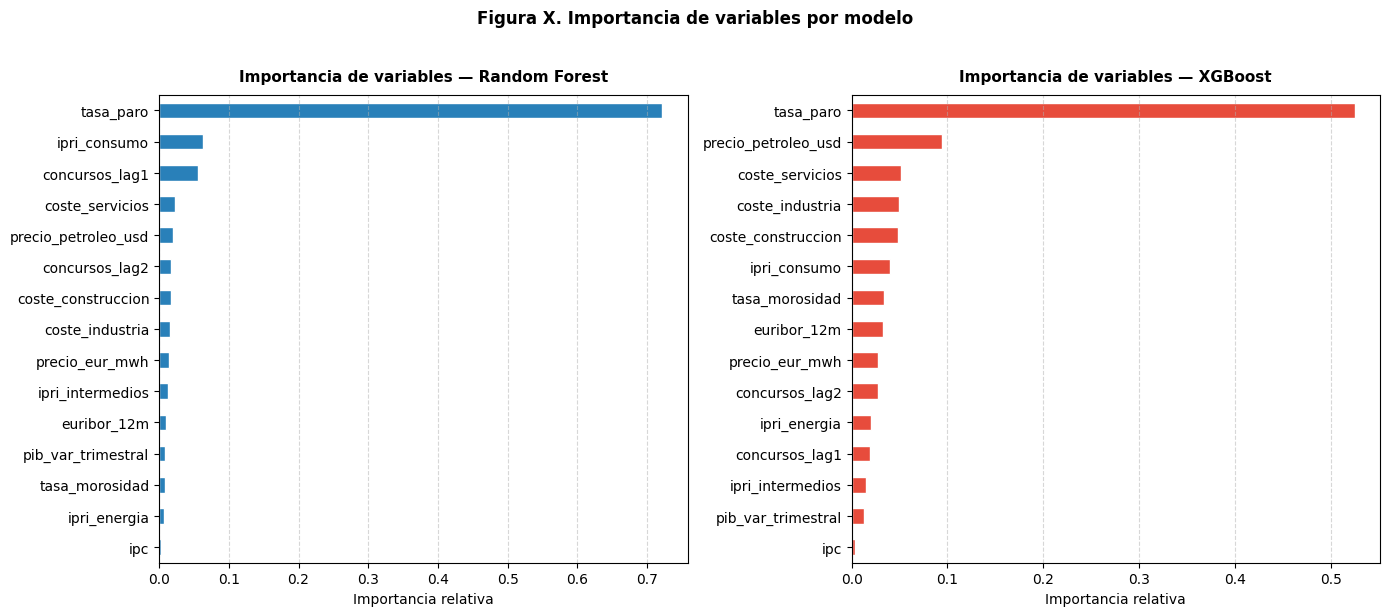

✅ Importancia guardada


In [26]:

# Random Forest y XGBoost calculan automáticamente la contribución de cada
# variable a la reducción del error del modelo. Se representa de forma comparada
# para identificar si ambos algoritmos coinciden en las variables más relevantes,
# lo que reforzaría la solidez del hallazgo.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, modelo, nombre, color in zip(
    axes, [modelo_rf, modelo_xgb], ['Random Forest', 'XGBoost'], ['#2980b9', '#e74c3c']
):
    importancias = pd.Series(modelo.feature_importances_, index=features).sort_values(ascending=True)
    importancias.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'Importancia de variables — {nombre}', fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Importancia relativa')
    ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.suptitle('Figura X. Importancia de variables por modelo', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/graphics/fig_importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Importancia guardada")

## ANALISIS INCREMENTAL DE VARIABLES -XGBoost

  6 vars | euribor_12m            | RMSE: 372.53 | R²: -4.2342
  7 vars | coste_construccion     | RMSE: 332.58 | R²: -3.1719
  8 vars | pib_var_trimestral     | RMSE: 316.77 | R²: -2.7846
  9 vars | coste_industria        | RMSE: 291.58 | R²: -2.2067
  10 vars | coste_servicios        | RMSE: 301.49 | R²: -2.4282
  11 vars | ipri_energia           | RMSE: 317.98 | R²: -2.8136
  12 vars | ipc                    | RMSE: 316.66 | R²: -2.7820
  13 vars | ipri_consumo           | RMSE: 326.58 | R²: -3.0225
  14 vars | ipri_intermedios       | RMSE: 319.74 | R²: -2.8559
  15 vars | precio_eur_mwh         | RMSE: 271.59 | R²: -1.7820


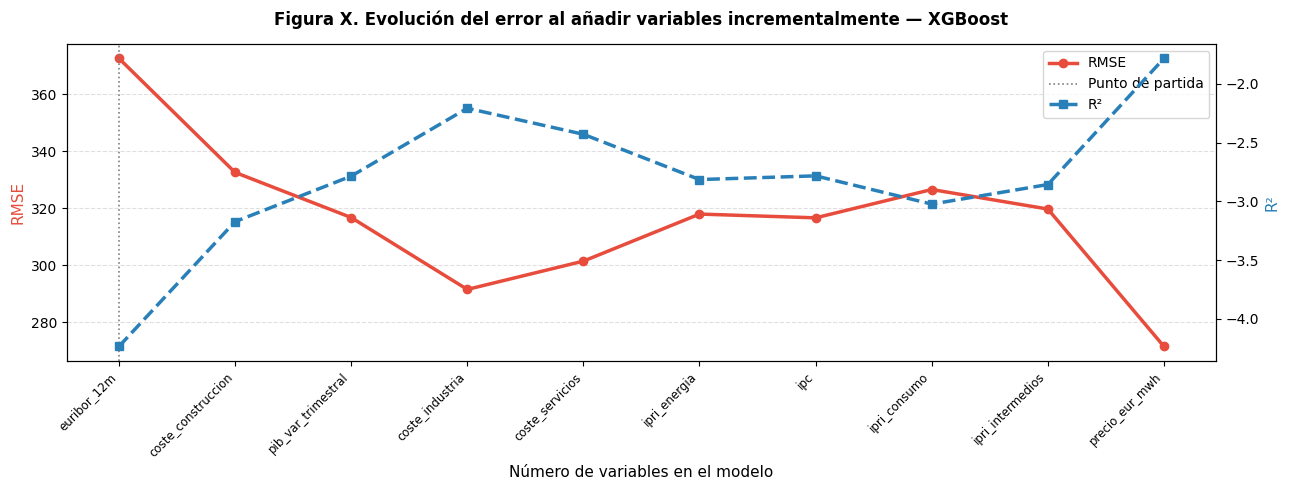

 Gráfico de métricas incrementales guardado


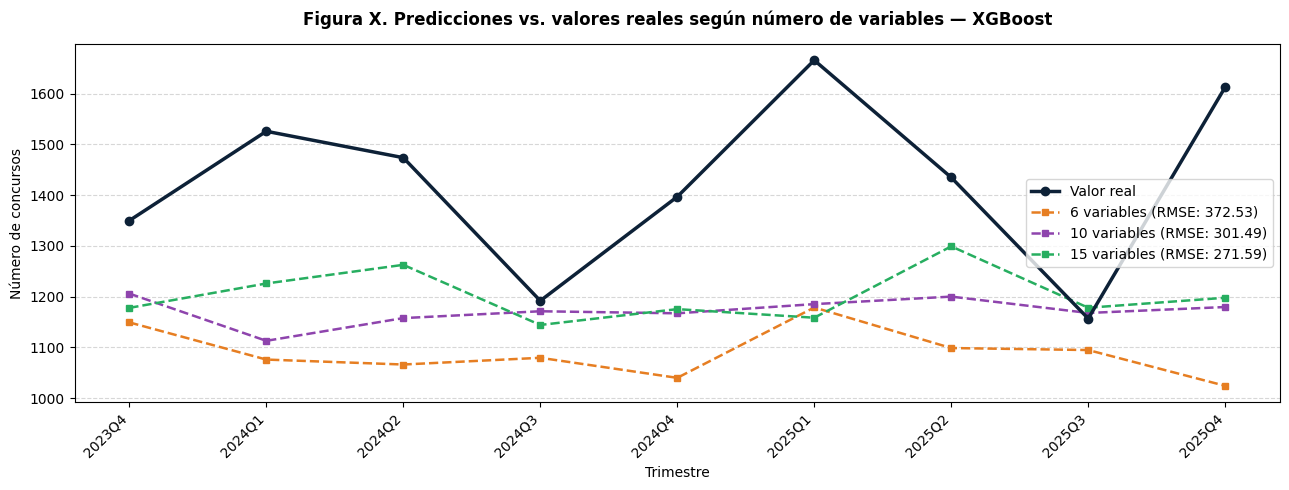

Gráfico de predicciones incrementales guardado


In [29]:

# Se evalúa cómo evoluciona el error del modelo a medida que se incorporan
# variables de forma progresiva, ordenadas por correlación absoluta con la
# variable objetivo (de mayor a menor). El análisis arranca con las 6 variables
# más correlacionadas y añade una nueva en cada iteración hasta completar las 15.
# El objetivo es identificar qué variables aportan información marginal real
# y en qué punto el modelo deja de beneficiarse de nuevos predictores.
variables_orden = [
    'concursos_lag1',      # correlación 0.73 — mayor correlación con target
    'precio_petroleo_usd', # correlación 0.61
    'concursos_lag2',      # correlación 0.60
    'tasa_paro',           # correlación 0.59
    'tasa_morosidad',      # correlación 0.48
    'euribor_12m',         # correlación 0.14 ← punto de partida (6 variables)
    'coste_construccion',  # correlación 0.14
    'pib_var_trimestral',  # correlación 0.01
    'coste_industria',     # correlación 0.04
    'coste_servicios',     # correlación 0.04
    'ipri_energia',        # correlación 0.07
    'ipc',                 # correlación 0.15
    'ipri_consumo',        # correlación 0.15
    'ipri_intermedios',    # correlación 0.17
    'precio_eur_mwh',      # correlación 0.26 ← variable final añadida
]

# Se reutilizan los hiperparámetros óptimos encontrados en el GridSearchCV
params_xgb = grid_xgb.best_params_.copy()
params_xgb['random_state'] = 42
params_xgb['verbosity'] = 0

resultados_incr = []
for n in range(6, len(variables_orden) + 1):
    vars_activas = variables_orden[:n]
    modelo = XGBRegressor(**params_xgb)
    modelo.fit(df_train[vars_activas], y_train)
    pred = modelo.predict(df_test[vars_activas])
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)
    resultados_incr.append({
        'n_vars': n, 'ultima_var': vars_activas[-1],
        'RMSE': round(rmse, 2), 'R²': round(r2, 4), 'pred': pred.copy()
    })
    print(f"  {n} vars | {vars_activas[-1]:<22} | RMSE: {rmse:.2f} | R²: {r2:.4f}")

ns    = [r['n_vars']     for r in resultados_incr]
rmses = [r['RMSE']       for r in resultados_incr]
r2s   = [r['R²']         for r in resultados_incr]
etiq  = [r['ultima_var'] for r in resultados_incr]

# Gráfico 1: evolución de RMSE y R² al añadir variables
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()
ax1.plot(ns, rmses, color='#e74c3c', linewidth=2.5, marker='o', markersize=6, label='RMSE')
ax2.plot(ns, r2s,   color='#2980b9', linewidth=2.5, marker='s', markersize=6,
         linestyle='--', label='R²')
ax1.set_xlabel('Número de variables en el modelo', fontsize=11)
ax1.set_ylabel('RMSE', color='#e74c3c', fontsize=11)
ax2.set_ylabel('R²',   color='#2980b9', fontsize=11)
ax1.set_xticks(ns)
ax1.set_xticklabels(etiq, rotation=45, ha='right', fontsize=8.5)
ax1.axvline(x=6, color='gray', linestyle=':', linewidth=1.2, label='Punto de partida')
ax1.grid(axis='y', linestyle='--', alpha=0.4)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.title('Figura X. Evolución del error al añadir variables incrementalmente — XGBoost',
          fontsize=12, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('../data/graphics/fig_incremento_variables_metricas.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Gráfico de métricas incrementales guardado")

# Gráfico 2: predicciones vs real en tres momentos clave del análisis incremental
# Se comparan los modelos con 6, 10 y 15 variables para visualizar
# cómo la curva predicha se acerca progresivamente al valor real.
momentos = [6, 10, 15]
colores_momentos = ['#e67e22', '#8e44ad', '#27ae60']
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(periodos_test, y_test.values, color='#0d2137', linewidth=2.5,
        marker='o', markersize=6, label='Valor real', zorder=5)
for momento, color in zip(momentos, colores_momentos):
    r = next(x for x in resultados_incr if x['n_vars'] == momento)
    ax.plot(periodos_test, r['pred'], color=color, linewidth=1.8,
            linestyle='--', marker='s', markersize=4,
            label=f"{momento} variables (RMSE: {r['RMSE']})")
ax.set_title('Figura X. Predicciones vs. valores reales según número de variables — XGBoost',
             fontsize=12, fontweight='bold', pad=14)
ax.set_xlabel('Trimestre')
ax.set_ylabel('Número de concursos')
ax.set_xticks(periodos_test)
ax.set_xticklabels(periodos_test, rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.savefig('../data/graphics/fig_incremento_variables_predicciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico de predicciones incrementales guardado")

## MODELO SIN TASA DE PARO

El análisis de importancia de variables reveló que tasa_paro acapara más del 70% del peso en Random Forest y el 52% en XGBoost, lo que indica una posible sobredependencia. Dado que en el período test (2024–2025) el paro se sitúa en niveles históricamente bajos mientras los concursos se mantienen relativamente elevados, se plantea un experimento de robustez eliminando esta variable para comprobar si los modelos generalizan mejor apoyándose en el resto de predictores. Una mejora significativa confirmaría que tasa_paro estaba distorsionando el aprendizaje; la ausencia de mejora señalaría que el problema es estructural del dataset y no imputable a ninguna variable concreta.


COMPARATIVA CON Y SIN TASA_PARO:
                   Modelo   RMSE    MAE      R²
 RL — todas las variables 178.64 136.42 -0.2036
       RL — sin tasa_paro 170.03 147.63 -0.0903
 RF — todas las variables 313.07 268.72 -2.6966
       RF — sin tasa_paro 298.78 249.81 -2.3669
XGB — todas las variables 300.42 254.87 -2.4039
      XGB — sin tasa_paro 303.38 254.68 -2.4714


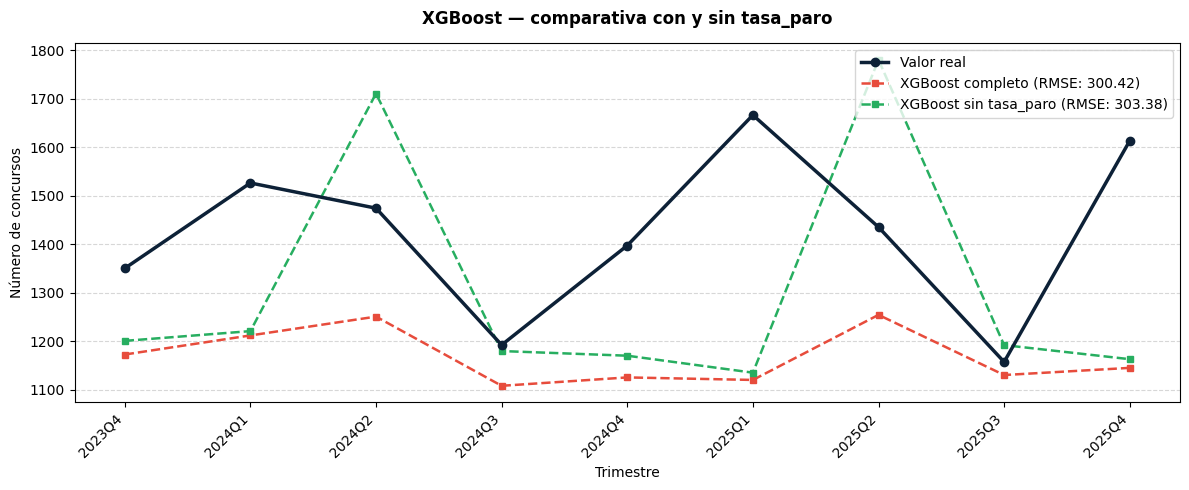

In [30]:
features_sin_paro = [f for f in features if f != 'tasa_paro']

X_train_sp = df_train[features_sin_paro]
X_test_sp  = df_test[features_sin_paro]

# Escalado para regresión lineal
X_train_sp_sc = scaler.fit_transform(X_train_sp)
X_test_sp_sc  = scaler.transform(X_test_sp)

# Regresión Lineal sin tasa_paro
modelo_rl_sp = LinearRegression()
modelo_rl_sp.fit(X_train_sp_sc, y_train)
pred_rl_sp = modelo_rl_sp.predict(X_test_sp_sc)

# Random Forest sin tasa_paro
grid_rf_sp = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf,
                          cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf_sp.fit(X_train_sp, y_train)
modelo_rf_sp = grid_rf_sp.best_estimator_
pred_rf_sp = modelo_rf_sp.predict(X_test_sp)

# XGBoost sin tasa_paro
grid_xgb_sp = GridSearchCV(XGBRegressor(random_state=42, verbosity=0), param_grid_xgb,
                            cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_xgb_sp.fit(X_train_sp, y_train)
modelo_xgb_sp = grid_xgb_sp.best_estimator_
pred_xgb_sp = modelo_xgb_sp.predict(X_test_sp)

# Métricas comparativas
resultados_sp = pd.DataFrame([
    evaluar('RL — todas las variables',   y_test, pred_rl),
    evaluar('RL — sin tasa_paro',         y_test, pred_rl_sp),
    evaluar('RF — todas las variables',   y_test, pred_rf),
    evaluar('RF — sin tasa_paro',         y_test, pred_rf_sp),
    evaluar('XGB — todas las variables',  y_test, pred_xgb),
    evaluar('XGB — sin tasa_paro',        y_test, pred_xgb_sp),
])
print("\nCOMPARATIVA CON Y SIN TASA_PARO:")
print(resultados_sp.to_string(index=False))

# Gráfico predicciones — XGBoost con y sin tasa_paro
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(periodos_test, y_test.values, color='#0d2137', linewidth=2.5,
        marker='o', markersize=6, label='Valor real', zorder=5)
ax.plot(periodos_test, pred_xgb,    color='#e74c3c', linewidth=1.8,
        linestyle='--', marker='s', markersize=4, label=f'XGBoost completo (RMSE: {resultados_sp.iloc[4]["RMSE"]})')
ax.plot(periodos_test, pred_xgb_sp, color='#27ae60', linewidth=1.8,
        linestyle='--', marker='s', markersize=4, label=f'XGBoost sin tasa_paro (RMSE: {resultados_sp.iloc[5]["RMSE"]})')
ax.set_title('XGBoost — comparativa con y sin tasa_paro',
             fontsize=12, fontweight='bold', pad=14)
ax.set_xlabel('Trimestre')
ax.set_ylabel('Número de concursos')
ax.set_xticks(periodos_test)
ax.set_xticklabels(periodos_test, rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.savefig('../data/graphics/fig_experimento_sin_paro.png', dpi=150, bbox_inches='tight')
plt.show()
